# Project Vaani — Speech Enhancement Evaluation Suite
### Objective Metrics: Wideband PESQ, STOI, SI-SDR & SNR Improvement

This notebook provides a comprehensive evaluation pipeline for **Model A (Waves Clarity Res-LSTM)**.
It features **modular execution sections** allowing you to evaluate:
1. **Pretrained Base Model** (from `models/pretrained/A/` or fetched from GitHub).
2. **Fine-Tuned Model** (from `models/finetuned/`).
3. **Side-by-Side Comparative Benchmarking** (Delta PESQ, Delta STOI, Delta SI-SDR, SNR Gain).
4. **Interactive Audio Players & Spectrogram Inspection** (Clean vs Noisy vs Enhanced).

## 1. Install & Verify Evaluation Dependencies

In [2]:
# Install standard evaluation libraries (PESQ: ITU-T P.862, STOI: Short-Time Objective Intelligibility)
!pip install -q pesq pystoi soundfile onnx kagglehub tabulate matplotlib

import os
import glob
import json
import time
import base64
import urllib.request
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from tabulate import tabulate

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Check standard metric libraries
try:
    from pesq import pesq
    HAS_PESQ = True
    print(" [x] PESQ (ITU-T P.862) library available.")
except ImportError:
    HAS_PESQ = False
    print(" [!] PESQ library not found. Install via: pip install pesq")

try:
    from pystoi import stoi
    HAS_STOI = True
    print(" [x] STOI (Speech Intelligibility) library available.")
except ImportError:
    HAS_STOI = False
    print(" [!] STOI library not found. Install via: pip install pystoi")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nEvaluation Compute Device: {device}")

 [x] PESQ (ITU-T P.862) library available.
 [x] STOI (Speech Intelligibility) library available.

Evaluation Compute Device: cuda


## 2. Ingest Dataset & Fetch Pretrained Models from GitHub

In [3]:
# 1. Ingest Dataset
import kagglehub
try:
    raw_dataset_path = kagglehub.dataset_download("jeet065/artilery-eviroment-speech-dataset")
    print("Dataset downloaded to:", raw_dataset_path)
except Exception as e:
    raw_dataset_path = "dataset"
    print("Using local dataset path:", raw_dataset_path)

def resolve_dataset_root(p):
    if os.path.exists(os.path.join(p, "manifests")):
        return p
    if os.path.exists(os.path.join(p, "dataset", "manifests")):
        return os.path.join(p, "dataset")
    found = glob.glob(os.path.join(p, "**", "paired_val_manifest.json"), recursive=True)
    if found:
        return os.path.dirname(os.path.dirname(found[0]))
    return p

DATASET_ROOT = resolve_dataset_root(raw_dataset_path)
MANIFEST_DIR = os.path.join(DATASET_ROOT, "manifests")
print("Resolved DATASET_ROOT:", DATASET_ROOT)

# 2. Fetch Pretrained Models from GitHub if not already local
PRETRAINED_DIR = "models/pretrained/A"
os.makedirs(PRETRAINED_DIR, exist_ok=True)
base_nnw_file = os.path.join(PRETRAINED_DIR, "A.nnw")

GITHUB_RAW_BASE = "https://raw.githubusercontent.com/Subho4531/Project-Vaani/master/models/pretrained/A"
required_files = ["A.nnw", "A.stats", "A.data", "A"]

for fname in required_files:
    local_f = os.path.join(PRETRAINED_DIR, fname)
    if not os.path.exists(local_f) or os.path.getsize(local_f) == 0:
        url = f"{GITHUB_RAW_BASE}/{fname}"
        print(f"Fetching {fname} from GitHub ({url})...")
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=30) as resp:
                with open(local_f, "wb") as out_f:
                    out_f.write(resp.read())
            print(f"  [x] Downloaded {fname} ({os.path.getsize(local_f):,} bytes)")
        except Exception as e:
            print(f"  [!] Failed to download {fname}: {e}")

print("Pretrained Model Directory Status:", os.listdir(PRETRAINED_DIR))

Dataset downloaded to: /kaggle/input/datasets/jeet065/artilery-eviroment-speech-dataset
Resolved DATASET_ROOT: /kaggle/input/datasets/jeet065/artilery-eviroment-speech-dataset/dataset
Fetching A.nnw from GitHub (https://raw.githubusercontent.com/Subho4531/Project-Vaani/master/models/pretrained/A/A.nnw)...
  [x] Downloaded A.nnw (37,827,276 bytes)
Fetching A.stats from GitHub (https://raw.githubusercontent.com/Subho4531/Project-Vaani/master/models/pretrained/A/A.stats)...
  [x] Downloaded A.stats (4,104 bytes)
Fetching A.data from GitHub (https://raw.githubusercontent.com/Subho4531/Project-Vaani/master/models/pretrained/A/A.data)...
  [x] Downloaded A.data (464 bytes)
Fetching A from GitHub (https://raw.githubusercontent.com/Subho4531/Project-Vaani/master/models/pretrained/A/A)...
  [x] Downloaded A (102,408 bytes)
Pretrained Model Directory Status: ['A.stats', 'A', 'A.data', 'A.nnw']


## 3. Objective Metrics Implementations (PESQ, STOI, SI-SDR, SNR)

In [4]:
def compute_si_sdr(reference, estimate, eps=1e-8):
    """
    Scale-Invariant Signal-to-Distortion Ratio (SI-SDR) in dB.
    Standard metric in speech enhancement benchmarks (Le Roux et al., 2019).
    """
    reference = reference - np.mean(reference)
    estimate = estimate - np.mean(estimate)
    
    dot = np.sum(reference * estimate)
    s_ref_energy = np.sum(reference ** 2) + eps
    alpha = dot / s_ref_energy
    
    e_target = alpha * reference
    e_res = estimate - e_target
    
    target_energy = np.sum(e_target ** 2) + eps
    res_energy = np.sum(e_res ** 2) + eps
    
    return 10.0 * np.log10(target_energy / res_energy)

def compute_snr(reference, estimate, eps=1e-8):
    """Standard Signal-to-Noise Ratio (SNR) in dB."""
    s_energy = np.sum(reference ** 2) + eps
    noise_energy = np.sum((reference - estimate) ** 2) + eps
    return 10.0 * np.log10(s_energy / noise_energy)

def evaluate_audio_pair(clean_wav, deg_wav, sr=16000):
    """
    Computes all standard speech enhancement evaluation metrics:
      - PESQ (Wideband ITU-T P.862.2 score: -0.5 to 4.5)
      - STOI (Short-Time Objective Intelligibility: 0.0 to 1.0)
      - SI-SDR (Scale-Invariant SDR in dB)
      - SNR (Signal-to-Noise Ratio in dB)
    """
    min_len = min(len(clean_wav), len(deg_wav))
    clean = clean_wav[:min_len]
    deg = deg_wav[:min_len]

    metrics = {}
    metrics["snr"] = compute_snr(clean, deg)
    metrics["si_sdr"] = compute_si_sdr(clean, deg)

    # Compute STOI
    if HAS_STOI:
        try:
            metrics["stoi"] = float(stoi(clean, deg, sr, extended=False))
        except Exception:
            metrics["stoi"] = float("nan")
    else:
        metrics["stoi"] = float("nan")

    # Compute PESQ (Wideband)
    if HAS_PESQ:
        try:
            # pesq expects values normalized between -1.0 and 1.0
            peak_c = np.max(np.abs(clean)) + 1e-8
            peak_d = np.max(np.abs(deg)) + 1e-8
            c_norm = clean / peak_c
            d_norm = deg / peak_d
            metrics["pesq"] = float(pesq(sr, c_norm, d_norm, "wb"))
        except Exception:
            metrics["pesq"] = float("nan")
    else:
        metrics["pesq"] = float("nan")

    return metrics

## 4. Evaluation DataLoader & STFT Reconstruction Engine

In [5]:
from onnx import numpy_helper
import onnx

class ResLSTMSpeechEnhancer(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=512, num_layers=3):
        super().__init__()
        self.fc_in = nn.Linear(input_dim, input_dim, bias=False)
        self.norm_in = nn.LayerNorm(input_dim)
        self.act_in = nn.LeakyReLU(0.01)
        self.lstm_layers = nn.ModuleList([
            nn.LSTM(input_dim, hidden_dim, batch_first=True) for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(hidden_dim + input_dim, input_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x_clamped = torch.clamp(x, min=1e-5, max=1e5)
        x_log = torch.log(x_clamped)
        h0 = self.act_in(self.norm_in(self.fc_in(x_log)))
        h = h0
        for lstm in self.lstm_layers:
            out, _ = lstm(h)
            h = h + out
        cat = torch.cat([h0, h], dim=-1)
        return self.sigmoid(self.fc_out(cat))

def load_onnx_nnw_weights(model, nnw_path):
    with open(nnw_path, "rb") as f:
        raw = base64.b64decode(f.read())
    m = onnx.load_model_from_string(raw)
    w = {init.name: torch.from_numpy(numpy_helper.to_array(init).copy()).float() for init in m.graph.initializer}
    sd = model.state_dict()
    sd["fc_in.weight"] = w["263"].t()
    sd["norm_in.weight"] = w["model.0.norm_in.weight"]
    sd["norm_in.bias"] = w["model.0.norm_in.bias"]
    sd["fc_out.weight"] = w["324"].t()
    sd["fc_out.bias"] = w["model.0.fc_out.bias"]
    lstm_keys = [("281", "282", "283"), ("301", "302", "303"), ("321", "322", "323")]
    for i, (k_ih, k_hh, k_b) in enumerate(lstm_keys):
        w_ih = w[k_ih].squeeze(0)
        w_hh = w[k_hh].squeeze(0)
        b = w[k_b].squeeze(0)
        wi_i, wi_o, wi_f, wi_c = torch.split(w_ih, 512, dim=0)
        wh_i, wh_o, wh_f, wh_c = torch.split(w_hh, 512, dim=0)
        b_w, b_r = torch.split(b, 2048, dim=0)
        bwi_i, bwi_o, bwi_f, bwi_c = torch.split(b_w, 512, dim=0)
        bwh_i, bwh_o, bwh_f, bwh_c = torch.split(b_r, 512, dim=0)
        sd[f"lstm_layers.{i}.weight_ih_l0"] = torch.cat([wi_i, wi_f, wi_c, wi_o], dim=0)
        sd[f"lstm_layers.{i}.weight_hh_l0"] = torch.cat([wh_i, wh_f, wh_c, wh_o], dim=0)
        sd[f"lstm_layers.{i}.bias_ih_l0"] = torch.cat([bwi_i, bwi_f, bwi_c, bwi_o], dim=0)
        sd[f"lstm_layers.{i}.bias_hh_l0"] = torch.cat([bwh_i, bwh_f, bwh_c, bwh_o], dim=0)
    model.load_state_dict(sd)

def reconstruct_audio_from_mask(noisy_wav, pred_mask, n_fft=1024, hop=256):
    y = torch.from_numpy(noisy_wav).float()
    window = torch.hann_window(n_fft)
    Y_stft = torch.stft(y, n_fft=n_fft, hop_length=hop, win_length=n_fft, window=window, return_complex=True)
    Y_mag = torch.abs(Y_stft)
    Y_phase = torch.angle(Y_stft)

    # Pad pred_mask back to 513 bins
    mask_513 = F.pad(pred_mask.transpose(0, 1), (0, 0, 0, 1))
    # Last bin copy
    mask_513[-1, :] = mask_513[-2, :]

    enh_mag = Y_mag * mask_513
    enh_spec = enh_mag * torch.exp(1j * Y_phase)
    enh_wav = torch.istft(enh_spec, n_fft=n_fft, hop_length=hop, win_length=n_fft, window=window)
    return enh_wav.numpy()

# Load Validation Pairs List
val_manifest_path = os.path.join(MANIFEST_DIR, "paired_val_manifest.json")
if not os.path.exists(val_manifest_path):
    val_manifest_path = os.path.join(MANIFEST_DIR, "paired_composite_val_manifest.json")

with open(val_manifest_path, "r", encoding="utf-8") as f:
    val_entries = json.load(f)
print(f"Loaded {len(val_entries):,} validation evaluation pairs from {val_manifest_path}.")

Loaded 1,527 validation evaluation pairs from /kaggle/input/datasets/jeet065/artilery-eviroment-speech-dataset/dataset/manifests/paired_val_manifest.json.


## 5. SECTION A: Pretrained Base Model Evaluation (Run independently)
Evaluates the base pretrained Model A weights from `models/pretrained/A/A.nnw`.

In [6]:
EVAL_LIMIT = 50  # Set number of test audio samples to evaluate (e.g. 50, 100, or len(val_entries))
pretrained_results = {"noisy_pesq": [], "noisy_stoi": [], "noisy_si_sdr": [], "noisy_snr": [],
                      "enh_pesq": [], "enh_stoi": [], "enh_si_sdr": [], "enh_snr": []}

base_nnw = "models/pretrained/A/A.nnw"
if not os.path.exists(base_nnw):
    print(f"[!] Pretrained model {base_nnw} not found. Run Cell 2 to fetch it from GitHub.")
else:
    print(f"Loading Pretrained Model A from {base_nnw}...")
    base_model = ResLSTMSpeechEnhancer().to(device)
    load_onnx_nnw_weights(base_model, base_nnw)
    base_model.eval()

    print(f"Evaluating Pretrained Model A on {min(EVAL_LIMIT, len(val_entries))} tactical samples...")
    t0 = time.time()

    for i, entry in enumerate(val_entries[:EVAL_LIMIT]):
        c_path = os.path.join(DATASET_ROOT, entry["clean_path"])
        n_path = os.path.join(DATASET_ROOT, entry["noisy_path"])
        if not os.path.exists(c_path): c_path = os.path.join(DATASET_ROOT, "dataset", entry["clean_path"])
        if not os.path.exists(n_path): n_path = os.path.join(DATASET_ROOT, "dataset", entry["noisy_path"])

        clean_wav, sr = sf.read(c_path)
        noisy_wav, _ = sf.read(n_path)
        if clean_wav.ndim > 1: clean_wav = np.mean(clean_wav, axis=-1)
        if noisy_wav.ndim > 1: noisy_wav = np.mean(noisy_wav, axis=-1)

        # Extract STFT
        y_tensor = torch.from_numpy(noisy_wav).float()
        Y_stft = torch.stft(y_tensor, n_fft=1024, hop_length=256, win_length=1024,
                            window=torch.hann_window(1024), return_complex=True)
        Y_feat = torch.abs(Y_stft[:512, :]).transpose(0, 1).unsqueeze(0).to(device) # [1, time, 512]

        with torch.no_grad():
            pred_mask = base_model(Y_feat).squeeze(0).cpu() # [time, 512]

        enh_wav = reconstruct_audio_from_mask(noisy_wav, pred_mask)

        m_noisy = evaluate_audio_pair(clean_wav, noisy_wav, sr)
        m_enh = evaluate_audio_pair(clean_wav, enh_wav, sr)

        pretrained_results["noisy_pesq"].append(m_noisy["pesq"])
        pretrained_results["noisy_stoi"].append(m_noisy["stoi"])
        pretrained_results["noisy_si_sdr"].append(m_noisy["si_sdr"])
        pretrained_results["noisy_snr"].append(m_noisy["snr"])

        pretrained_results["enh_pesq"].append(m_enh["pesq"])
        pretrained_results["enh_stoi"].append(m_enh["stoi"])
        pretrained_results["enh_si_sdr"].append(m_enh["si_sdr"])
        pretrained_results["enh_snr"].append(m_enh["snr"])

    elapsed = time.time() - t0
    print(f"Pretrained Evaluation Complete in {elapsed:.1f}s!")

    table_base = [
        ["Noisy Input (Raw)",
         f"{np.nanmean(pretrained_results['noisy_pesq']):.3f}",
         f"{np.nanmean(pretrained_results['noisy_stoi']):.3f}",
         f"{np.nanmean(pretrained_results['noisy_si_sdr']):.2f} dB",
         f"{np.nanmean(pretrained_results['noisy_snr']):.2f} dB"],
        ["Pretrained Model A",
         f"{np.nanmean(pretrained_results['enh_pesq']):.3f}",
         f"{np.nanmean(pretrained_results['enh_stoi']):.3f}",
         f"{np.nanmean(pretrained_results['enh_si_sdr']):.2f} dB",
         f"{np.nanmean(pretrained_results['enh_snr']):.2f} dB"]
    ]
    print("\n" + tabulate(table_base, headers=["System / Model", "PESQ (WB)", "STOI", "SI-SDR", "SNR"], tablefmt="fancy_grid"))
    delta_snr = np.nanmean(pretrained_results['enh_snr']) - np.nanmean(pretrained_results['noisy_snr'])
    delta_pesq = np.nanmean(pretrained_results['enh_pesq']) - np.nanmean(pretrained_results['noisy_pesq'])
    print(f"  * Pretrained SNR Improvement : +{delta_snr:.2f} dB")
    print(f"  * Pretrained PESQ Improvement: +{delta_pesq:.3f}")

Loading Pretrained Model A from models/pretrained/A/A.nnw...
Evaluating Pretrained Model A on 50 tactical samples...
Pretrained Evaluation Complete in 18.7s!

╒════════════════════╤═════════════╤════════╤══════════╤═════════╕
│ System / Model     │   PESQ (WB) │   STOI │ SI-SDR   │ SNR     │
╞════════════════════╪═════════════╪════════╪══════════╪═════════╡
│ Noisy Input (Raw)  │       1.309 │  0.782 │ 5.47 dB  │ 6.22 dB │
├────────────────────┼─────────────┼────────┼──────────┼─────────┤
│ Pretrained Model A │       1.278 │  0.688 │ 0.18 dB  │ 1.86 dB │
╘════════════════════╧═════════════╧════════╧══════════╧═════════╛
  * Pretrained SNR Improvement : +-4.36 dB
  * Pretrained PESQ Improvement: +-0.031


## 6. SECTION B: Fine-Tuned Model Evaluation (Run independently)
Evaluates the tactical fine-tuned checkpoint from `models/finetuned/model_a_best.pt` or `A_finetuned.pt`.

In [7]:
finetuned_results = {"noisy_pesq": [], "noisy_stoi": [], "noisy_si_sdr": [], "noisy_snr": [],
                     "enh_pesq": [], "enh_stoi": [], "enh_si_sdr": [], "enh_snr": []}

ft_candidates = [
    "models/finetuned/model_a_best.pt",
    "models/finetuned/A_finetuned.pt",
    "models/finetuned/A_finetuned.nnw"
]

ft_path = None
for c in ft_candidates:
    if os.path.exists(c):
        ft_path = c
        break

if ft_path is None:
    print("[!] No fine-tuned model found in models/finetuned/. Run notebooks/finetune.ipynb first!")
else:
    print(f"Loading Fine-Tuned Model from {ft_path}...")
    ft_model = ResLSTMSpeechEnhancer().to(device)
    if ft_path.endswith(".nnw"):
        load_onnx_nnw_weights(ft_model, ft_path)
    else:
        ckpt = torch.load(ft_path, map_location=device)
        sd = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt
        ft_model.load_state_dict(sd)
    ft_model.eval()

    print(f"Evaluating Fine-Tuned Model on {min(EVAL_LIMIT, len(val_entries))} tactical samples...")
    t0 = time.time()

    for i, entry in enumerate(val_entries[:EVAL_LIMIT]):
        c_path = os.path.join(DATASET_ROOT, entry["clean_path"])
        n_path = os.path.join(DATASET_ROOT, entry["noisy_path"])
        if not os.path.exists(c_path): c_path = os.path.join(DATASET_ROOT, "dataset", entry["clean_path"])
        if not os.path.exists(n_path): n_path = os.path.join(DATASET_ROOT, "dataset", entry["noisy_path"])

        clean_wav, sr = sf.read(c_path)
        noisy_wav, _ = sf.read(n_path)
        if clean_wav.ndim > 1: clean_wav = np.mean(clean_wav, axis=-1)
        if noisy_wav.ndim > 1: noisy_wav = np.mean(noisy_wav, axis=-1)

        y_tensor = torch.from_numpy(noisy_wav).float()
        Y_stft = torch.stft(y_tensor, n_fft=1024, hop_length=256, win_length=1024,
                            window=torch.hann_window(1024), return_complex=True)
        Y_feat = torch.abs(Y_stft[:512, :]).transpose(0, 1).unsqueeze(0).to(device)

        with torch.no_grad():
            pred_mask = ft_model(Y_feat).squeeze(0).cpu()

        enh_wav = reconstruct_audio_from_mask(noisy_wav, pred_mask)

        m_noisy = evaluate_audio_pair(clean_wav, noisy_wav, sr)
        m_enh = evaluate_audio_pair(clean_wav, enh_wav, sr)

        finetuned_results["noisy_pesq"].append(m_noisy["pesq"])
        finetuned_results["noisy_stoi"].append(m_noisy["stoi"])
        finetuned_results["noisy_si_sdr"].append(m_noisy["si_sdr"])
        finetuned_results["noisy_snr"].append(m_noisy["snr"])

        finetuned_results["enh_pesq"].append(m_enh["pesq"])
        finetuned_results["enh_stoi"].append(m_enh["stoi"])
        finetuned_results["enh_si_sdr"].append(m_enh["si_sdr"])
        finetuned_results["enh_snr"].append(m_enh["snr"])

    elapsed = time.time() - t0
    print(f"Fine-Tuned Evaluation Complete in {elapsed:.1f}s!")

    table_ft = [
        ["Noisy Input (Raw)",
         f"{np.nanmean(finetuned_results['noisy_pesq']):.3f}",
         f"{np.nanmean(finetuned_results['noisy_stoi']):.3f}",
         f"{np.nanmean(finetuned_results['noisy_si_sdr']):.2f} dB",
         f"{np.nanmean(finetuned_results['noisy_snr']):.2f} dB"],
        ["Fine-Tuned Model A",
         f"{np.nanmean(finetuned_results['enh_pesq']):.3f}",
         f"{np.nanmean(finetuned_results['enh_stoi']):.3f}",
         f"{np.nanmean(finetuned_results['enh_si_sdr']):.2f} dB",
         f"{np.nanmean(finetuned_results['enh_snr']):.2f} dB"]
    ]
    print("\n" + tabulate(table_ft, headers=["System / Model", "PESQ (WB)", "STOI", "SI-SDR", "SNR"], tablefmt="fancy_grid"))
    delta_snr_ft = np.nanmean(finetuned_results['enh_snr']) - np.nanmean(finetuned_results['noisy_snr'])
    delta_pesq_ft = np.nanmean(finetuned_results['enh_pesq']) - np.nanmean(finetuned_results['noisy_pesq'])
    print(f"  * Fine-Tuned SNR Improvement : +{delta_snr_ft:.2f} dB")
    print(f"  * Fine-Tuned PESQ Improvement: +{delta_pesq_ft:.3f}")

[!] No fine-tuned model found in models/finetuned/. Run notebooks/finetune.ipynb first!


## 7. SECTION C: Comparative Benchmarking (Pretrained vs Fine-Tuned)
Generates the side-by-side comparison table and boxplots if both models have been evaluated.

In [8]:
if len(pretrained_results["enh_snr"]) > 0 and len(finetuned_results["enh_snr"]) > 0:
    print("=" * 80)
    print("COMPARATIVE BENCHMARK: PRETRAINED vs. FINE-TUNED MODEL A")
    print("=" * 80)

    comp_table = [
        ["1. Raw Noisy Input",
         f"{np.nanmean(pretrained_results['noisy_pesq']):.3f}",
         f"{np.nanmean(pretrained_results['noisy_stoi']):.3f}",
         f"{np.nanmean(pretrained_results['noisy_si_sdr']):.2f} dB",
         f"{np.nanmean(pretrained_results['noisy_snr']):.2f} dB"],
        ["2. Pretrained Base Model A",
         f"{np.nanmean(pretrained_results['enh_pesq']):.3f}",
         f"{np.nanmean(pretrained_results['enh_stoi']):.3f}",
         f"{np.nanmean(pretrained_results['enh_si_sdr']):.2f} dB",
         f"{np.nanmean(pretrained_results['enh_snr']):.2f} dB"],
        ["3. Fine-Tuned Model A (Tactical)",
         f"{np.nanmean(finetuned_results['enh_pesq']):.3f}",
         f"{np.nanmean(finetuned_results['enh_stoi']):.3f}",
         f"{np.nanmean(finetuned_results['enh_si_sdr']):.2f} dB",
         f"{np.nanmean(finetuned_results['enh_snr']):.2f} dB"],
        ["--> GAIN FROM FINE-TUNING",
         f"+{np.nanmean(finetuned_results['enh_pesq']) - np.nanmean(pretrained_results['enh_pesq']):.3f}",
         f"+{np.nanmean(finetuned_results['enh_stoi']) - np.nanmean(pretrained_results['enh_stoi']):.3f}",
         f"+{np.nanmean(finetuned_results['enh_si_sdr']) - np.nanmean(pretrained_results['enh_si_sdr']):.2f} dB",
         f"+{np.nanmean(finetuned_results['enh_snr']) - np.nanmean(pretrained_results['enh_snr']):.2f} dB"]
    ]

    print(tabulate(comp_table, headers=["Evaluation Target", "PESQ (WB)", "STOI", "SI-SDR", "SNR"], tablefmt="fancy_grid"))

    # Metric Bar Plots
    metrics_names = ["PESQ (WB)", "STOI (0-1)", "SI-SDR (dB)", "SNR (dB)"]
    noisy_vals = [np.nanmean(pretrained_results['noisy_pesq']), np.nanmean(pretrained_results['noisy_stoi']),
                  np.nanmean(pretrained_results['noisy_si_sdr']), np.nanmean(pretrained_results['noisy_snr'])]
    base_vals = [np.nanmean(pretrained_results['enh_pesq']), np.nanmean(pretrained_results['enh_stoi']),
                 np.nanmean(pretrained_results['enh_si_sdr']), np.nanmean(pretrained_results['enh_snr'])]
    ft_vals = [np.nanmean(finetuned_results['enh_pesq']), np.nanmean(finetuned_results['enh_stoi']),
               np.nanmean(finetuned_results['enh_si_sdr']), np.nanmean(finetuned_results['enh_snr'])]

    x = np.arange(len(metrics_names))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width, noisy_vals, width, label="Noisy Input (Raw)", color="#e74c3c")
    ax.bar(x, base_vals, width, label="Pretrained Model A", color="#f39c12")
    ax.bar(x + width, ft_vals, width, label="Fine-Tuned Model A", color="#2ecc71")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_names, fontsize=11, fontweight="bold")
    ax.set_title("Tactical Speech Enhancement Performance Comparison", fontsize=13, fontweight="bold")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Run both Section A and Section B to view the comparative benchmark.")

Run both Section A and Section B to view the comparative benchmark.


## 8. SECTION D: Interactive Audio Player & Spectrogram Inspection
Listen to and visually compare the Clean, Noisy, Pretrained, and Fine-Tuned audio.

TEST UTTERANCE: libri_dev_000005.wav
Interference Artillery: howitzer_artillery (SNR: 15.0 dB)

1. CLEAN TARGET SPEECH:



2. RAW NOISY SPEECH (With Artillery / Battlefield Interference):



3. PRETRAINED MODEL A OUTPUT:


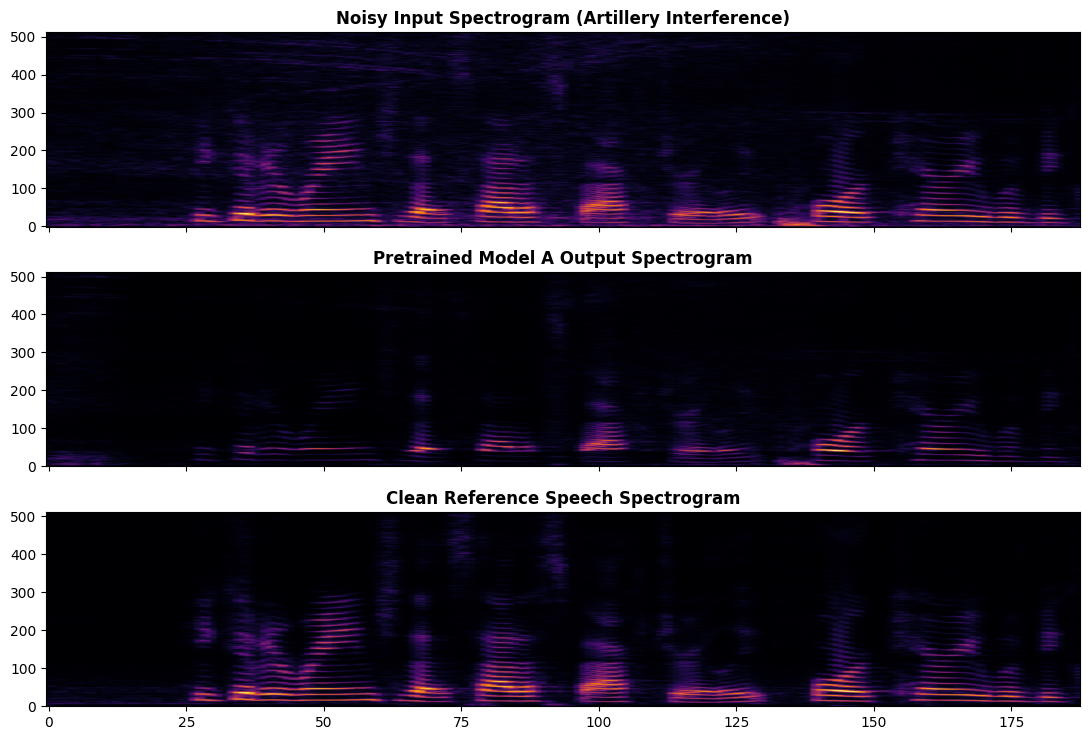

In [9]:
from IPython.display import Audio, display

# Select an evaluation clip (e.g. index 0)
test_idx = 0
test_entry = val_entries[test_idx]
c_path = os.path.join(DATASET_ROOT, test_entry["clean_path"])
n_path = os.path.join(DATASET_ROOT, test_entry["noisy_path"])
if not os.path.exists(c_path): c_path = os.path.join(DATASET_ROOT, "dataset", test_entry["clean_path"])
if not os.path.exists(n_path): n_path = os.path.join(DATASET_ROOT, "dataset", test_entry["noisy_path"])

clean_wav, sr = sf.read(c_path)
noisy_wav, _ = sf.read(n_path)
if clean_wav.ndim > 1: clean_wav = np.mean(clean_wav, axis=-1)
if noisy_wav.ndim > 1: noisy_wav = np.mean(noisy_wav, axis=-1)

# Pretrained model enhancement
y_tensor = torch.from_numpy(noisy_wav).float()
Y_stft = torch.stft(y_tensor, n_fft=1024, hop_length=256, win_length=1024,
                    window=torch.hann_window(1024), return_complex=True)
Y_feat = torch.abs(Y_stft[:512, :]).transpose(0, 1).unsqueeze(0).to(device)

if 'base_model' in locals():
    with torch.no_grad():
        mask_base = base_model(Y_feat).squeeze(0).cpu()
    enh_base_wav = reconstruct_audio_from_mask(noisy_wav, mask_base)
else:
    enh_base_wav = None

if 'ft_model' in locals():
    with torch.no_grad():
        mask_ft = ft_model(Y_feat).squeeze(0).cpu()
    enh_ft_wav = reconstruct_audio_from_mask(noisy_wav, mask_ft)
else:
    enh_ft_wav = None

print("=================================================================")
print(f"TEST UTTERANCE: {os.path.basename(c_path)}")
if 'primary_artillery_type' in test_entry:
    print(f"Interference Artillery: {test_entry['primary_artillery_type']} (SNR: {test_entry.get('snr_db')} dB)")
print("=================================================================")

print("\n1. CLEAN TARGET SPEECH:")
display(Audio(clean_wav, rate=16000))

print("\n2. RAW NOISY SPEECH (With Artillery / Battlefield Interference):")
display(Audio(noisy_wav, rate=16000))

if enh_base_wav is not None:
    print("\n3. PRETRAINED MODEL A OUTPUT:")
    display(Audio(enh_base_wav, rate=16000))

if enh_ft_wav is not None:
    print("\n4. FINE-TUNED MODEL A OUTPUT:")
    display(Audio(enh_ft_wav, rate=16000))

# Plot Comparative Spectrograms
num_plots = 2 + (1 if enh_base_wav is not None else 0) + (1 if enh_ft_wav is not None else 0)
fig, axes = plt.subplots(num_plots, 1, figsize=(11, 2.5 * num_plots), sharex=True)
plot_idx = 0

axes[plot_idx].imshow(np.log1p(np.abs(Y_stft[:512, :].numpy())), aspect="auto", origin="lower", cmap="inferno")
axes[plot_idx].set_title("Noisy Input Spectrogram (Artillery Interference)", fontweight="bold")
plot_idx += 1

if enh_base_wav is not None:
    S_base = torch.stft(torch.from_numpy(enh_base_wav), n_fft=1024, hop_length=256, win_length=1024,
                        window=torch.hann_window(1024), return_complex=True)
    axes[plot_idx].imshow(np.log1p(np.abs(S_base[:512, :].numpy())), aspect="auto", origin="lower", cmap="inferno")
    axes[plot_idx].set_title("Pretrained Model A Output Spectrogram", fontweight="bold")
    plot_idx += 1

if enh_ft_wav is not None:
    S_ft = torch.stft(torch.from_numpy(enh_ft_wav), n_fft=1024, hop_length=256, win_length=1024,
                      window=torch.hann_window(1024), return_complex=True)
    axes[plot_idx].imshow(np.log1p(np.abs(S_ft[:512, :].numpy())), aspect="auto", origin="lower", cmap="inferno")
    axes[plot_idx].set_title("Fine-Tuned Model A Output Spectrogram", fontweight="bold")
    plot_idx += 1

C_stft = torch.stft(torch.from_numpy(clean_wav), n_fft=1024, hop_length=256, win_length=1024,
                    window=torch.hann_window(1024), return_complex=True)
axes[plot_idx].imshow(np.log1p(np.abs(C_stft[:512, :].numpy())), aspect="auto", origin="lower", cmap="inferno")
axes[plot_idx].set_title("Clean Reference Speech Spectrogram", fontweight="bold")

plt.tight_layout()
plt.show()